In [1]:
%pip install -U langchain langchain-openai langgraph-checkpoint-sqlite
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.6/151.6 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.1
    Uninstalling langchain-core-1.2.1:
      Successfully uninstalled langchain-core-1.2.1
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  

In [2]:
from google.colab import userdata
API_KEY = userdata.get('SILICONFLOW_API_KEY')
from langchain.chat_models import init_chat_model
from IPython.display import Image, display
# === LLM 初始化 ===
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key= API_KEY,
    temperature=0.0
)

def display_graph(app):
  # 使用 Graphviz 渲染（Colab 最稳定的方案）
  try:
      display(Image(app.get_graph(xray=True).draw_png()))
  except Exception as e:
      print(f"Graphviz 渲染失败: {e}")
      print("\n使用 Mermaid 文本方式显示:")
      print(app.get_graph(xray=True).draw_mermaid())

## 条件路由与循环

### 1.1 条件路由回顾

在第1课中，我们学习了基本的条件边。现在深入学习更复杂的路由模式。

**基本条件路由：**

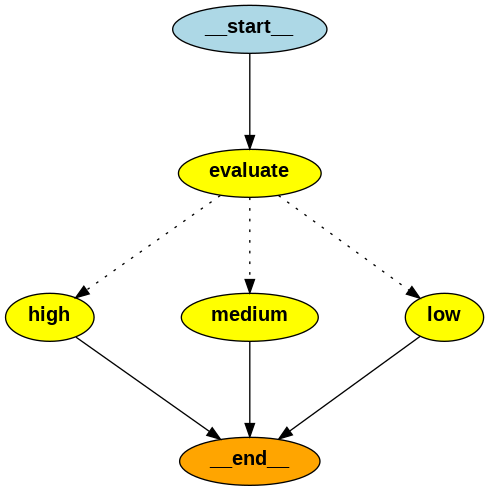

In [3]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    score: float
    decision: str

def evaluate(state: State) -> dict:
    """评估并打分"""
    return {"score": 0.75}

def route_by_score(state: State) -> Literal["high", "medium", "low"]:
    """根据分数路由"""
    score = state["score"]
    if score > 0.8:
        return "high"
    elif score > 0.5:
        return "medium"
    else:
        return "low"

def handle_high(state: State) -> dict:
    return {"decision": "自动通过"}

def handle_medium(state: State) -> dict:
    return {"decision": "人工审核"}

def handle_low(state: State) -> dict:
    return {"decision": "自动拒绝"}

# 构建图
graph = StateGraph(State)
graph.add_node("evaluate", evaluate)
graph.add_node("high", handle_high)
graph.add_node("medium", handle_medium)
graph.add_node("low", handle_low)

graph.add_edge(START, "evaluate")
graph.add_conditional_edges(
    "evaluate",
    route_by_score,
    {
        "high": "high",
        "medium": "medium",
        "low": "low"
    }
)

for node in ["high", "medium", "low"]:
    graph.add_edge(node, END)

app = graph.compile()
display_graph(app)

### 1.2 LLM 驱动的路由

**使用 LLM 做决策：**

In [4]:
from langchain.messages import HumanMessage, SystemMessage
import json

class AgentState(TypedDict):
    messages: list
    next_action: str


def llm_router(state: AgentState) -> Literal["search", "calculate", "respond", "clarify"]:
    """LLM 决定下一步行动"""
    messages = state["messages"]
    last_message = messages[-1].content

    routing_prompt = f"""
分析用户的请求，决定下一步行动：

用户请求：{last_message}

可选行动：
- search: 需要搜索信息
- calculate: 需要计算
- respond: 可以直接回复
- clarify: 需要澄清用户意图

只返回行动名称，不要解释。
"""

    response = model.invoke([HumanMessage(content=routing_prompt)])
    action = response.content.strip().lower()

    # 验证返回值
    valid_actions = ["search", "calculate", "respond", "clarify"]
    return action if action in valid_actions else "clarify"

def search_node(state: AgentState) -> dict:
    """搜索节点"""
    print("🔍 执行搜索...")
    return {"next_action": "search"}

def calculate_node(state: AgentState) -> dict:
    """计算节点"""
    print("🧮 执行计算...")
    return {"next_action": "calculate"}

def respond_node(state: AgentState) -> dict:
    """回复节点"""
    print("💬 生成回复...")
    return {"next_action": "respond"}

def clarify_node(state: AgentState) -> dict:
    """澄清节点"""
    print("❓ 请求澄清...")
    return {"next_action": "clarify"}

### 1.3 多级路由

**先粗筛后细分：**

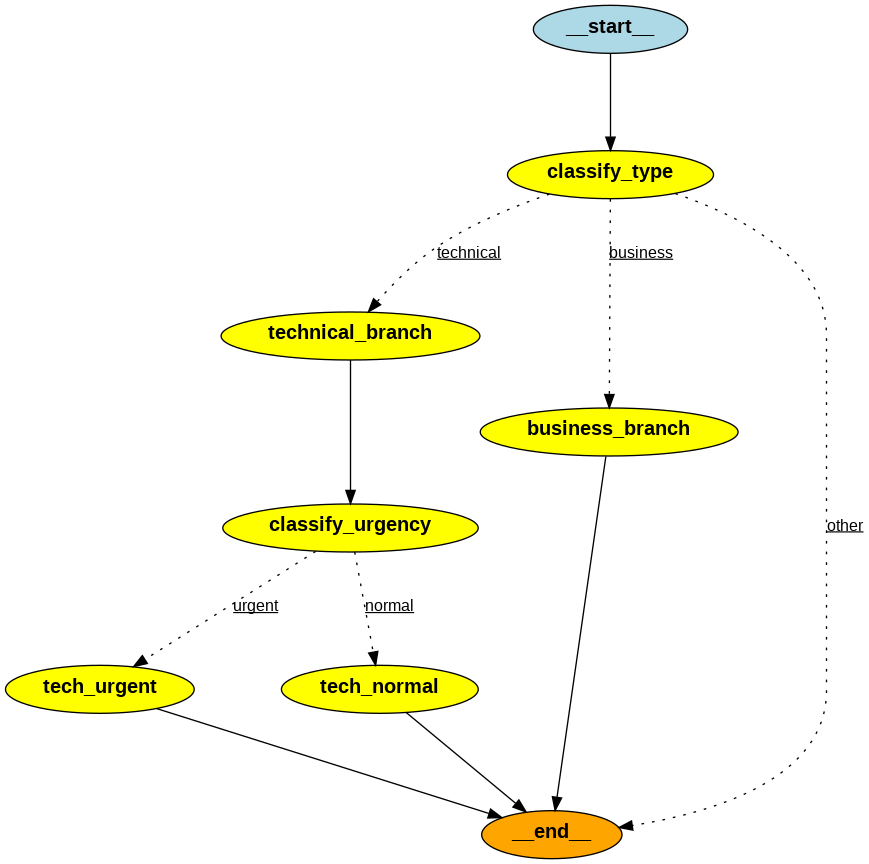

In [5]:
class MultiLevelState(TypedDict):
    content_type: str
    urgency: str
    assigned_team: str

def classify_content_type(state: MultiLevelState) -> Literal["technical", "business", "other"]:
    """第一级：内容类型分类"""
    # 实际应用中使用 LLM
    return "technical"

def classify_urgency(state: MultiLevelState) -> Literal["urgent", "normal"]:
    """第二级：紧急程度分类"""
    return "urgent"

def assign_technical_urgent(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术紧急响应组"}

def assign_technical_normal(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术支持组"}

# 构建多级路由图
graph = StateGraph(MultiLevelState)

# 第一级分类
graph.add_node("classify_type", lambda s: {})
graph.add_node("technical_branch", lambda s: {})
graph.add_node("business_branch", lambda s: {})

# 第二级分类（technical 分支）
graph.add_node("classify_urgency", lambda s: {})
graph.add_node("tech_urgent", assign_technical_urgent)
graph.add_node("tech_normal", assign_technical_normal)

graph.add_edge(START, "classify_type")
graph.add_conditional_edges(
    "classify_type",
    classify_content_type,
    {
        "technical": "technical_branch",
        "business": "business_branch",
        "other": END
    }
)

graph.add_edge("technical_branch", "classify_urgency")
graph.add_conditional_edges(
    "classify_urgency",
    classify_urgency,
    {
        "urgent": "tech_urgent",
        "normal": "tech_normal"
    }
)

graph.add_edge("tech_urgent", END)
graph.add_edge("tech_normal", END)
graph.add_edge("business_branch", END)

app = graph.compile()
display_graph(app)

### 1.4 循环模式

**Agent 的思考-行动循环：**

🤔 思考中... (迭代 1)
⚡ 执行工具...
🤔 思考中... (迭代 2)
⚡ 执行工具...
🤔 思考中... (迭代 3)
⚡ 执行工具...
🤔 思考中... (迭代 4)
⚡ 执行工具...
🤔 思考中... (迭代 5)


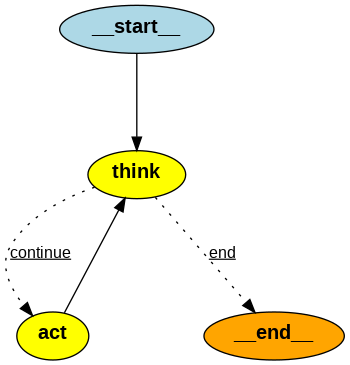

In [6]:
from typing import Annotated
from langgraph.graph.message import add_messages

class AgentLoopState(TypedDict):
    messages: Annotated[list, add_messages]
    iterations: int
    max_iterations: int
    final_answer: str

def should_continue(state: AgentLoopState) -> Literal["continue", "end"]:
    """决定是否继续循环"""
    # 检查是否有最终答案
    if state.get("final_answer"):
        return "end"

    # 检查是否超过最大迭代次数
    if state["iterations"] >= state["max_iterations"]:
        return "end"

    return "continue"

def think_node(state: AgentLoopState) -> dict:
    """思考节点"""
    print(f"🤔 思考中... (迭代 {state['iterations'] + 1})")

    # LLM 推理
    messages = state["messages"]
    response = model.invoke(messages)

    # 检查是否有答案
    if "最终答案：" in response.content:
        return {
            "final_answer": response.content,
            "iterations": state["iterations"] + 1
        }

    return {
        "messages": [response],
        "iterations": state["iterations"] + 1
    }

def act_node(state: AgentLoopState) -> dict:
    """行动节点（执行工具）"""
    print("⚡ 执行工具...")

    # 执行工具，获取结果
    tool_result = "工具执行结果..."

    return {
        "messages": [HumanMessage(content=f"观察：{tool_result}")]
    }

# 构建循环图
loop_graph = StateGraph(AgentLoopState)
loop_graph.add_node("think", think_node)
loop_graph.add_node("act", act_node)

loop_graph.add_edge(START, "think")
loop_graph.add_conditional_edges(
    "think",
    should_continue,
    {
        "continue": "act",
        "end": END
    }
)
loop_graph.add_edge("act", "think")  # 形成循环

loop_app = loop_graph.compile()

# 运行
result = loop_app.invoke({
    "messages": [HumanMessage(content="帮我查询北京今天的天气")],
    "iterations": 0,
    "max_iterations": 5,
    "final_answer": ""
})

display_graph(loop_app)

## 2. Streaming：流式输出

### 2.1 为什么需要 Streaming？

在长时间运行的任务中，用户希望看到实时进度：

- ✅ 更好的用户体验
- ✅ 实时反馈
- ✅ Token-by-Token 输出
- ✅ 监控任务进度

### 2.2 三种 Streaming 模式

**模式 1：values - 完整状态**

“给我看最新的完整剧本。”

- 传输内容：返回图的当前完整 State（状态）。

- 触发时机：每个节点（Node）执行结束后。

- 数据格式：包含 State 中定义的所有字段（即使某些字段没变，也会一起返回）。

适用场景：

- 你需要前端页面始终同步展示所有的上下文信息。

- 调试时想看每一步执行完后，整体状态变成了什么样。

缺点：如果 State 非常大（比如存了上百轮对话历史），每次都传输全量数据会浪费带宽。



```
# 第1步返回：
{"messages": [HumanMessage(...)], "user_info": {...}}
# 第2步返回（包含第1步的内容）：
{"messages": [HumanMessage(...), AIMessage(...)], "user_info": {...}}
```



**模式 2：updates - 状态更新**

“告诉我刚刚发生了什么变化。”
- 传输内容：返回刚刚执行完的那个节点所产出的输出（即对 State 的修改量）。
- 触发时机：每个节点（Node）执行结束后。
- 数据格式：一个字典，Key 是节点名称，Value 是该节点的输出结果。

适用场景：
- 构建多 Agent 系统时，想知道具体是“哪个 Agent”在干活，以及它产出了什么。
- 节省带宽，只传输变化的数据。[3]
- 前端只需要追加显示新产生的消息，而不需要刷新整个页面。




```
# 只有"chatbot"节点刚运行完，只返回它的更新
{"chatbot": {"messages": [AIMessage(content="Hello")]}}
```



**模式 3：messages - Token 流**

“别等说完，想到一个字就告诉我一个字。”

- 传输内容：LLM 生成的**Token（词元）**以及相关的元数据。
- 触发时机：在节点执行过程中，LLM 生成内容的瞬间（实时）。
- 数据格式：通常是 (message_chunk, metadata) 的元组。
- 核心区别： 前两种模式都要等一个节点彻底跑完代码才返回数据（Step-by-step），而 messages 是在节点内部一边跑一边返回（Token-by-token）。

适用场景：
- ChatGPT 式的打字机效果：让用户感觉 AI 响应很快，不用等整个回复生成完。
- 实时反馈：在长文本生成任务中提供视觉反馈。


返回示例：

```
# 连续快速返回
("H", {...}), ("el", {...}), ("lo", {...}), ("!", {...})
```




LangGraph 允许你同时开启多种模式。例如，你可能既想要 updates 来知道是哪个 Agent 在说话，又想要 messages 来实现打字机效果



```
# 同时获取更新和 Token 流
async for chunk in graph.astream(inputs, stream_mode=["updates", "messages"]):
    # chunk 可能是更新对象，也可能是 token 消息，需要根据类型处理
    print(chunk)
```



2.3 实战：进度条显示

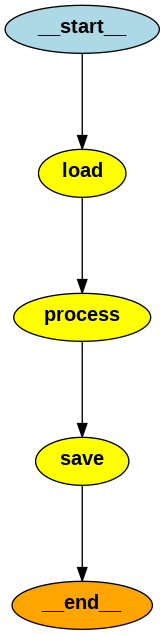


处理任务...
保存结果: [██████████████████████████████] 100% (100/100)
✅ 完成！


In [7]:
import time
from typing import TypedDict, Annotated
from operator import add

class ProcessingState(TypedDict):
    total_items: int
    processed_items: Annotated[int, add]
    current_step: str
    progress_pct: float

def step1(state: ProcessingState) -> dict:
    """数据加载"""
    time.sleep(1)
    return {
        "processed_items": 20,
        "current_step": "数据加载",
        "progress_pct": 20.0
    }

def step2(state: ProcessingState) -> dict:
    """数据处理"""
    time.sleep(1.5)
    return {
        "processed_items": 50,
        "current_step": "数据处理",
        "progress_pct": 70.0
    }

def step3(state: ProcessingState) -> dict:
    """保存结果"""
    time.sleep(0.5)
    return {
        "processed_items": 30,
        "current_step": "保存结果",
        "progress_pct": 100.0
    }

graph = StateGraph(ProcessingState)
graph.add_node("load", step1)
graph.add_node("process", step2)
graph.add_node("save", step3)

graph.add_edge(START, "load")
graph.add_edge("load", "process")
graph.add_edge("process", "save")
graph.add_edge("save", END)

app = graph.compile()
display_graph(app)

# 实时显示进度
print("\n处理任务...")
for state in app.stream({"total_items": 100, "processed_items": 0}, stream_mode="values"):
    step = state.get("current_step", "初始化")
    progress = state.get("progress_pct", 0)
    processed = state.get("processed_items", 0)

    bar_length = 30
    filled = int(bar_length * progress / 100)
    bar = "█" * filled + "░" * (bar_length - filled)

    print(f"\r{step}: [{bar}] {progress:.0f}% ({processed}/100)", end="", flush=True)

print("\n✅ 完成！")

### 2.4 Streaming + Checkpoint

In [8]:
from langgraph.checkpoint.memory import MemorySaver

# 带 checkpoint 的 streaming
checkpointer = MemorySaver()
app_with_checkpoint = graph.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "task-1"}}

print("\n=== Streaming with Checkpoint ===")
for chunk in app_with_checkpoint.stream(
    {"total_items": 100, "processed_items": 0},
    config,
    stream_mode="updates"
):
    print(f"节点更新: {chunk}")

# 查看最终 checkpoint
final_state = app_with_checkpoint.get_state(config)
print(f"\n最终状态: {final_state.values}")


=== Streaming with Checkpoint ===
节点更新: {'load': {'processed_items': 20, 'current_step': '数据加载', 'progress_pct': 20.0}}
节点更新: {'process': {'processed_items': 50, 'current_step': '数据处理', 'progress_pct': 70.0}}
节点更新: {'save': {'processed_items': 30, 'current_step': '保存结果', 'progress_pct': 100.0}}

最终状态: {'total_items': 100, 'processed_items': 100, 'current_step': '保存结果', 'progress_pct': 100.0}


## 3. Interrupts：Human-in-the-Loop

### 3.1 什么是 Interrupt？

**Interrupt** 允许图在特定节点暂停，等待外部输入（通常是人工干预）。

**使用场景：**

- ✅ 人工审核
- ✅ 确认决策
- ✅ 提供额外信息
- ✅ 修改和重试

### 3.2 使用 interrupt()

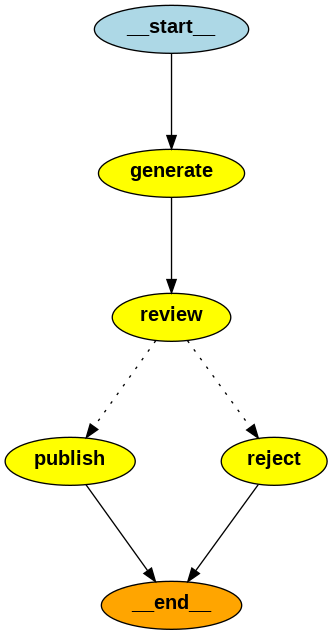


=== 第一次调用（会中断） ===
📝 生成内容...

⏸️  等待人工审核...
内容: 这是生成的内容...

状态: {'content': '这是生成的内容...', 'approved': False, '__interrupt__': [Interrupt(value={'question': '是否批准此内容？', 'options': ['approve', 'reject', 'request_changes']}, id='751e0b8973b49d6bff37fbf449d8ebf8')]}

中断状态: ('review',)

=== 提供审核决策并继续 ===

⏸️  等待人工审核...
内容: 这是生成的内容...

最终结果: {'content': '这是生成的内容...', 'approved': True, '__interrupt__': [Interrupt(value={'question': '是否批准此内容？', 'options': ['approve', 'reject', 'request_changes']}, id='97cf05d23e8fb8d35b5987161b98ead9')]}


In [9]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt

class ReviewState(TypedDict):
    content: str
    approved: bool
    feedback: str

def generate_content(state: ReviewState) -> dict:
    """生成内容"""
    print("📝 生成内容...")
    return {"content": "这是生成的内容..."}

def review_node(state: ReviewState) -> dict:
    """人工审核节点"""
    content = state["content"]

    print(f"\n{'='*50}")
    print("⏸️  等待人工审核...")
    print(f"内容: {content}")
    print(f"{'='*50}\n")

    # 暂停并等待人工输入
    approval = interrupt({
        "question": "是否批准此内容？",
        "options": ["approve", "reject", "request_changes"]
    })

    # 根据审核结果返回
    if approval == "approve":
        return {"approved": True, "feedback": "已批准"}
    elif approval == "reject":
        return {"approved": False, "feedback": "已拒绝"}
    else:
        return {"approved": False, "feedback": "需要修改"}

def publish_node(state: ReviewState) -> dict:
    """发布内容"""
    print("🚀 发布内容...")
    return {}

def reject_node(state: ReviewState) -> dict:
    """拒绝内容"""
    print("❌ 内容已拒绝")
    return {}

def should_publish(state: ReviewState) -> Literal["publish", "reject"]:
    """根据审核结果路由"""
    return "publish" if state.get("approved", False) else "reject"

# 构建图（必须使用 checkpointer）
graph = StateGraph(ReviewState)
graph.add_node("generate", generate_content)
graph.add_node("review", review_node)
graph.add_node("publish", publish_node)
graph.add_node("reject", reject_node)

graph.add_edge(START, "generate")
graph.add_edge("generate", "review")
graph.add_conditional_edges(
    "review",
    should_publish,
    {
        "publish": "publish",
        "reject": "reject"
    }
)
graph.add_edge("publish", END)
graph.add_edge("reject", END)

# 必须使用 checkpointer
checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)
display_graph(app)

# 运行
config = {"configurable": {"thread_id": "review-1"}}

print("\n=== 第一次调用（会中断） ===")
result = app.invoke({"content": "", "approved": False}, config)
print(f"状态: {result}")

# 检查是否中断
state = app.get_state(config)
print(f"\n中断状态: {state.next}")  # 应该显示等待继续的节点

# 提供审核决策并继续
print("\n=== 提供审核决策并继续 ===")
app.update_state(config, {"approved": True})  # 批准
result = app.invoke(None, config)  # 继续执行
print(f"最终结果: {result}")

### 带选项的 Interrupt

In [ ]:
def review_with_options(state: ReviewState) -> dict:
    """带多个选项的审核"""
    content = state["content"]

    # 提供结构化的选项
    decision = interrupt({
        "type": "review",
        "content": content,
        "options": [
            {"id": "approve", "label": "批准", "description": "内容无问题，批准发布"},
            {"id": "minor_edit", "label": "小修改", "description": "需要小幅修改"},
            {"id": "major_edit", "label": "大修改", "description": "需要重写"},
            {"id": "reject", "label": "拒绝", "description": "内容不合适，拒绝"}
        ]
    })

    return {"decision": decision}

## 4. Time Travel：时间旅行

### 4.1 什么是 Time Travel？

**Time Travel** 允许你：

- 查看完整的执行历史
- 回溯到任意历史状态
- 从历史状态创建新的分支

**使用场景：**

- ✅ 调试和分析
- ✅ A/B 测试
- ✅ 审计追踪
- ✅ 撤销操作

### 4.2 查看历史

In [10]:
from langgraph.checkpoint.memory import MemorySaver

class HistoryState(TypedDict):
    count: int
    history: list

def increment_node(state: HistoryState) -> dict:
    new_count = state.get("count", 0) + 1
    return {
        "count": new_count,
        "history": state.get("history", []) + [f"Incremented to {new_count}"]
    }

graph = StateGraph(HistoryState)
graph.add_node("inc1", increment_node)
graph.add_node("inc2", increment_node)
graph.add_node("inc3", increment_node)

graph.add_edge(START, "inc1")
graph.add_edge("inc1", "inc2")
graph.add_edge("inc2", "inc3")
graph.add_edge("inc3", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "history-demo"}}

# 运行
result = app.invoke({"count": 0, "history": []}, config)
print(f"最终结果: {result}")

# 查看历史
print("\n=== 执行历史 ===")
history = app.get_state_history(config)

for i, checkpoint in enumerate(history):
    print(f"\nCheckpoint {i + 1}:")
    print(f"  State: {checkpoint.values}")
    print(f"  Next: {checkpoint.next}")
    print(f"  Checkpoint ID: {checkpoint.config['configurable'].get('checkpoint_id')}")

最终结果: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}

=== 执行历史 ===

Checkpoint 1:
  State: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}
  Next: ()
  Checkpoint ID: 1f0dfa93-09df-6256-8003-c15592c7cfbd

Checkpoint 2:
  State: {'count': 2, 'history': ['Incremented to 1', 'Incremented to 2']}
  Next: ('inc3',)
  Checkpoint ID: 1f0dfa93-09dc-6cb4-8002-014ed6b1d17f

Checkpoint 3:
  State: {'count': 1, 'history': ['Incremented to 1']}
  Next: ('inc2',)
  Checkpoint ID: 1f0dfa93-09da-6063-8001-30216eb9f31f

Checkpoint 4:
  State: {'count': 0, 'history': []}
  Next: ('inc1',)
  Checkpoint ID: 1f0dfa93-09d7-601a-8000-b194d57db615

Checkpoint 5:
  State: {}
  Next: ('__start__',)
  Checkpoint ID: 1f0dfa93-09d4-6016-bfff-e7b6a25ab8ec


#### 4.3 回溯到历史状态

In [11]:
# 获取历史中的某个 checkpoint
history_list = list(app.get_state_history(config))

# 选择第 2 个 checkpoint（count = 1）
target_checkpoint = history_list[-3]  # 倒数第三个

print(f"\n回溯到: {target_checkpoint.values}")

# 从这个 checkpoint 继续执行（会创建新分支）
new_config = {
    "configurable": {
        "thread_id": "history-demo",
        "checkpoint_id": target_checkpoint.config["configurable"]["checkpoint_id"]
    }
}

# 继续执行
result = app.invoke(None, new_config)
print(f"从历史继续的结果: {result}")


回溯到: {'count': 1, 'history': ['Incremented to 1']}
从历史继续的结果: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}


#### 4.4 实战：可撤销的操作

In [ ]:
class UndoableState(TypedDict):
    data: list
    operation_history: list

def add_item(state: UndoableState) -> dict:
    """添加项目"""
    item = f"Item-{len(state.get('data', [])) + 1}"
    return {
        "data": state.get("data", []) + [item],
        "operation_history": state.get("operation_history", []) + [f"Added {item}"]
    }

def remove_item(state: UndoableState) -> dict:
    """移除最后一个项目"""
    data = state.get("data", [])
    if data:
        removed = data[-1]
        return {
            "data": data[:-1],
            "operation_history": state.get("operation_history", []) + [f"Removed {removed}"]
        }
    return {}

def undo_operation(app, config):
    """撤销最后一个操作"""
    # 获取历史
    history = list(app.get_state_history(config))

    if len(history) < 2:
        print("没有可撤销的操作")
        return

    # 获取倒数第二个状态（撤销最后一次操作）
    previous_state = history[1]

    print(f"撤销到: {previous_state.values}")

    # 更新到历史状态
    app.update_state(
        config,
        previous_state.values,
        as_node="__start__"
    )

# 示例使用
undo_graph = StateGraph(UndoableState)
undo_graph.add_node("add", add_item)
undo_graph.add_edge(START, "add")
undo_graph.add_edge("add", END)

undo_app = undo_graph.compile(checkpointer=MemorySaver())
display_graph(undo_app)
undo_config = {"configurable": {"thread_id": "undo-demo"}}

# 执行多个操作
print("\n执行操作...")
for i in range(3):
    result = undo_app.invoke({"data": [], "operation_history": []}, undo_config)
    print(f"操作 {i+1}: {result['data']}")

# 撤销
print("\n撤销最后一个操作...")
undo_operation(undo_app, undo_config)

state = undo_app.get_state(undo_config)
print(f"撤销后: {state.values['data']}")

## 5. 综合实战：交互式内容审核工作流

现在让我们构建一个完整的交互式内容审核系统，整合所有特性：

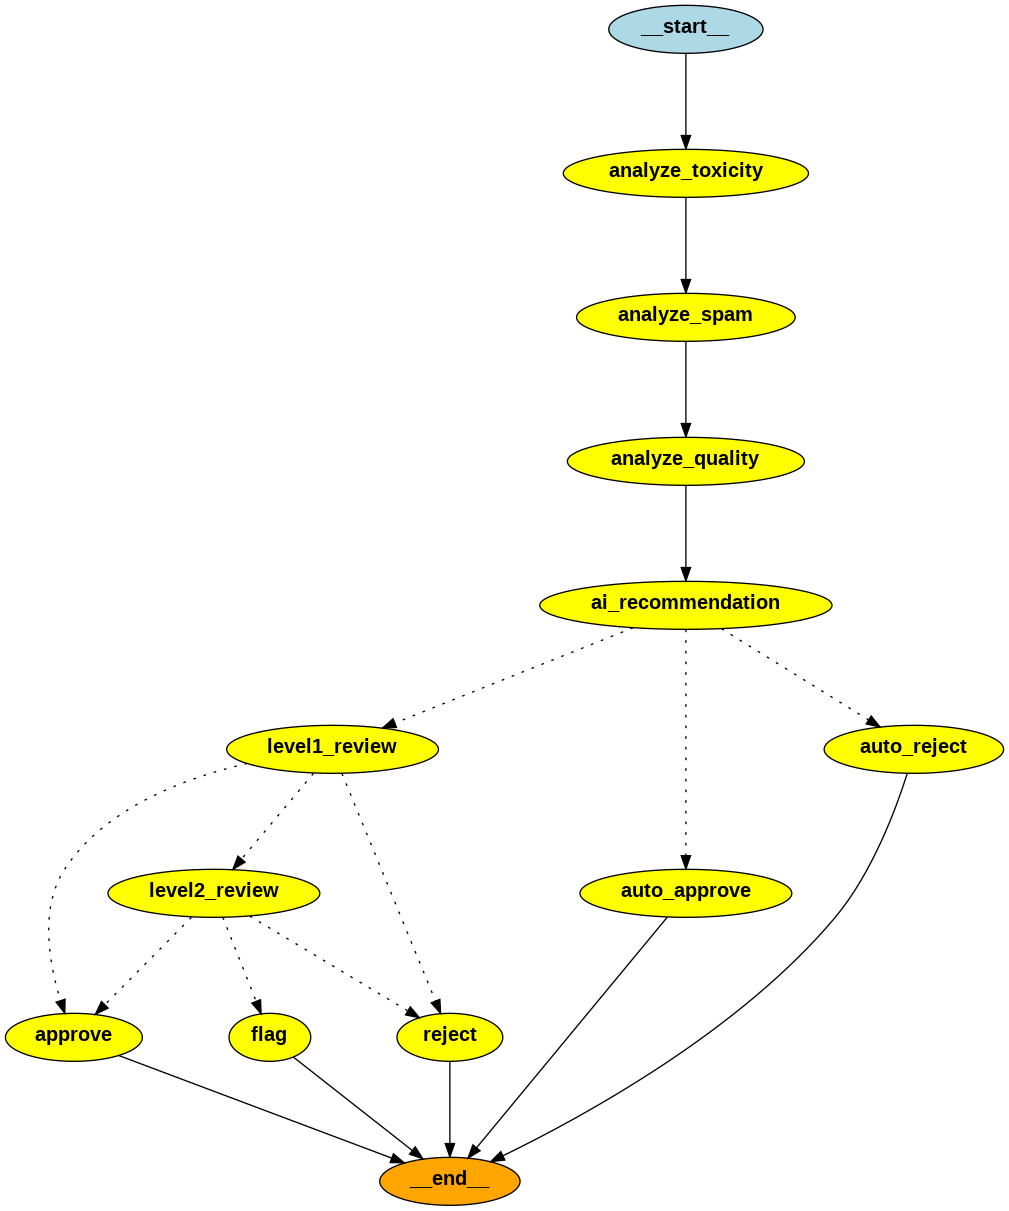

In [12]:
"""
综合实战：交互式内容审核工作流

功能：
- 自动内容分析
- 流式输出分析进度
- 多级人工审核（Interrupts）
- 历史追溯（Time Travel）
- 可撤销决策
"""

from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt
from langchain.messages import HumanMessage, SystemMessage
import sqlite3
import json
import time

# ============================================
# State 定义
# ============================================

class ContentReviewState(TypedDict):
    # 内容信息
    content_id: str
    content: str
    content_type: str  # "article", "comment", "post"

    # 分析结果
    toxicity_score: float
    spam_score: float
    quality_score: float
    ai_recommendation: str

    # 审核流程
    review_level: int  # 1, 2, 3
    reviewer_decisions: Annotated[list, lambda old, new: old + new]
    final_decision: str  # "approved", "rejected", "flagged"

    # 元数据
    processing_steps: Annotated[list, lambda old, new: old + new]
    created_at: str
    reviewed_at: str

# ============================================
# 分析节点
# ============================================


def analyze_toxicity(state: ContentReviewState) -> dict:
    """分析毒性"""
    print("🔍 分析毒性...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
分析以下内容的毒性（0.0-1.0）：
{content}

只返回数字。
"""

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.0

    return {
        "toxicity_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析毒性完成"]
    }

def analyze_spam(state: ContentReviewState) -> dict:
    """分析垃圾信息"""
    print("🔍 分析垃圾信息...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
分析以下内容是否为垃圾信息（0.0-1.0）：
{content}

只返回数字。
"""

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.0

    return {
        "spam_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析垃圾信息完成"]
    }

def analyze_quality(state: ContentReviewState) -> dict:
    """分析质量"""
    print("🔍 分析内容质量...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
分析以下内容的质量（0.0-1.0）：
{content}

只返回数字。
"""

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.5

    return {
        "quality_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析质量完成"]
    }

def make_ai_recommendation(state: ContentReviewState) -> dict:
    """AI 综合建议"""
    print("🤖 生成 AI 建议...")

    toxicity = state["toxicity_score"]
    spam = state["spam_score"]
    quality = state["quality_score"]

    # 规则基于的建议
    if toxicity > 0.7 or spam > 0.7:
        recommendation = "auto_reject"
    elif toxicity < 0.3 and spam < 0.3 and quality > 0.6:
        recommendation = "auto_approve"
    else:
        recommendation = "human_review"

    return {
        "ai_recommendation": recommendation,
        "processing_steps": ["AI 建议生成完成"]
    }

# ============================================
# 路由决策
# ============================================

def route_by_ai_recommendation(state: ContentReviewState) -> Literal["auto_approve", "auto_reject", "level1_review"]:
    """根据 AI 建议路由"""
    recommendation = state["ai_recommendation"]

    if recommendation == "auto_approve":
        return "auto_approve"
    elif recommendation == "auto_reject":
        return "auto_reject"
    else:
        return "level1_review"

def route_after_level1(state: ContentReviewState) -> Literal["approve", "level2_review", "reject"]:
    """一级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    if not decisions:
        return "level2_review"

    last_decision = decisions[-1]["decision"]

    if last_decision == "approve":
        return "approve"
    elif last_decision == "escalate":
        return "level2_review"
    else:
        return "reject"

def route_after_level2(state: ContentReviewState) -> Literal["approve", "reject", "flag"]:
    """二级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    if len(decisions) < 2:
        return "flag"

    last_decision = decisions[-1]["decision"]

    if last_decision == "approve":
        return "approve"
    elif last_decision == "flag":
        return "flag"
    else:
        return "reject"

# ============================================
# 审核节点
# ============================================

def level1_review_node(state: ContentReviewState) -> dict:
    """一级审核（Interrupt）"""
    print("\n" + "="*60)
    print("📋 一级审核")
    print("="*60)
    print(f"内容: {state['content']}")
    print(f"毒性分数: {state['toxicity_score']:.2f}")
    print(f"垃圾分数: {state['spam_score']:.2f}")
    print(f"质量分数: {state['quality_score']:.2f}")
    print("="*60 + "\n")

    # 中断，等待审核决策
    decision = interrupt({
        "type": "level1_review",
        "content": state["content"],
        "scores": {
            "toxicity": state["toxicity_score"],
            "spam": state["spam_score"],
            "quality": state["quality_score"]
        },
        "options": ["approve", "escalate", "reject"]
    })

    return {
        "review_level": 1,
        "reviewer_decisions": [{
            "level": 1,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": ["一级审核完成"]
    }

def level2_review_node(state: ContentReviewState) -> dict:
    """二级审核（高级）"""
    print("\n" + "="*60)
    print("📋 二级审核（高级）")
    print("="*60)
    print(f"内容: {state['content']}")
    print(f"一级审核决策: {state['reviewer_decisions']}")
    print("="*60 + "\n")

    decision = interrupt({
        "type": "level2_review",
        "content": state["content"],
        "previous_decisions": state["reviewer_decisions"],
        "options": ["approve", "reject", "flag"]
    })

    return {
        "review_level": 2,
        "reviewer_decisions": [{
            "level": 2,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": ["二级审核完成"]
    }

# ============================================
# 最终处理节点
# ============================================

def auto_approve_node(state: ContentReviewState) -> dict:
    """自动批准"""
    print("✅ 自动批准")
    return {
        "final_decision": "approved",
        "processing_steps": ["自动批准"]
    }

def auto_reject_node(state: ContentReviewState) -> dict:
    """自动拒绝"""
    print("❌ 自动拒绝")
    return {
        "final_decision": "rejected",
        "processing_steps": ["自动拒绝"]
    }

def approve_node(state: ContentReviewState) -> dict:
    """人工批准"""
    print("✅ 人工批准")
    return {
        "final_decision": "approved",
        "processing_steps": ["人工批准"]
    }

def reject_node(state: ContentReviewState) -> dict:
    """人工拒绝"""
    print("❌ 人工拒绝")
    return {
        "final_decision": "rejected",
        "processing_steps": ["人工拒绝"]
    }

def flag_node(state: ContentReviewState) -> dict:
    """标记"""
    print("🚩 标记为可疑")
    return {
        "final_decision": "flagged",
        "processing_steps": ["标记可疑"]
    }

# ============================================
# 构建图
# ============================================

review_graph = StateGraph(ContentReviewState)

# 分析节点
review_graph.add_node("analyze_toxicity", analyze_toxicity)
review_graph.add_node("analyze_spam", analyze_spam)
review_graph.add_node("analyze_quality", analyze_quality)
review_graph.add_node("ai_recommendation", make_ai_recommendation)

# 审核节点
review_graph.add_node("level1_review", level1_review_node)
review_graph.add_node("level2_review", level2_review_node)

# 决策节点
review_graph.add_node("auto_approve", auto_approve_node)
review_graph.add_node("auto_reject", auto_reject_node)
review_graph.add_node("approve", approve_node)
review_graph.add_node("reject", reject_node)
review_graph.add_node("flag", flag_node)

# 构建流程
review_graph.add_edge(START, "analyze_toxicity")
review_graph.add_edge("analyze_toxicity", "analyze_spam")
review_graph.add_edge("analyze_spam", "analyze_quality")
review_graph.add_edge("analyze_quality", "ai_recommendation")

review_graph.add_conditional_edges(
    "ai_recommendation",
    route_by_ai_recommendation,
    {
        "auto_approve": "auto_approve",
        "auto_reject": "auto_reject",
        "level1_review": "level1_review"
    }
)

review_graph.add_conditional_edges(
    "level1_review",
    route_after_level1,
    {
        "approve": "approve",
        "level2_review": "level2_review",
        "reject": "reject"
    }
)

review_graph.add_conditional_edges(
    "level2_review",
    route_after_level2,
    {
        "approve": "approve",
        "reject": "reject",
        "flag": "flag"
    }
)

# 所有终点流向 END
for node in ["auto_approve", "auto_reject", "approve", "reject", "flag"]:
    review_graph.add_edge(node, END)

# 编译（使用 SQLite checkpointer）
checkpointer = SqliteSaver(sqlite3.connect("content_review.db", check_same_thread=False))
review_app = review_graph.compile(checkpointer=checkpointer)

display_graph(review_app)



In [13]:
# ============================================
# 使用示例
# ============================================

def run_review_demo():
    """运行审核演示"""
    print("\n" + "="*60)
    print("交互式内容审核工作流演示")
    print("="*60 + "\n")

    # 测试内容
    test_content = "这是一条需要审核的用户评论。内容质量较好，没有明显问题。"

    config = {"configurable": {"thread_id": "review-001"}}

    # 初始运行（会在一级审核时中断）
    print("🚀 开始审核流程...\n")

    initial_state = {
        "content_id": "content-001",
        "content": test_content,
        "content_type": "comment",
        "toxicity_score": 0.0,
        "spam_score": 0.0,
        "quality_score": 0.0,
        "ai_recommendation": "",
        "review_level": 0,
        "reviewer_decisions": [],
        "final_decision": "",
        "processing_steps": [],
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "reviewed_at": ""
    }

    # Stream 运行，显示进度
    for chunk in review_app.stream(initial_state, config, stream_mode="updates"):
        for node_name, update in chunk.items():
            if "processing_steps" in update:
                steps = update["processing_steps"]
                for step in steps:
                    print(f"  ✓ {step}")

    # 检查状态
    state = review_app.get_state(config)
    print(f"\n当前状态: 等待 {state.next}")

    # 模拟一级审核决策
    print("\n👤 审核员决策: escalate（提交二级审核）")
    review_app.update_state(
        config,
        {
            "reviewer_decisions": [{
                "level": 1,
                "decision": "escalate",
                "timestamp": time.time()
            }]
        },
        as_node="level1_review"
    )

    # 继续执行
    print("\n继续执行...\n")
    for chunk in review_app.stream(None, config, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"  节点: {node_name}")

    # 查看历史
    print("\n" + "="*60)
    print("📜 执行历史")
    print("="*60)

    history = list(review_app.get_state_history(config))
    print(f"总共 {len(history)} 个检查点")

    for i, checkpoint in enumerate(history[:5]):  # 显示前5个
        print(f"\nCheckpoint {i+1}:")
        print(f"  决策: {checkpoint.values.get('final_decision', '进行中')}")
        print(f"  步骤: {checkpoint.values.get('processing_steps', [])[-1] if checkpoint.values.get('processing_steps') else 'N/A'}")

    print("\n" + "="*60)
    print("✅ 演示完成")
    print("="*60 + "\n")

if __name__ == "__main__":
  run_review_demo()


交互式内容审核工作流演示

🚀 开始审核流程...

🔍 分析毒性...
  ✓ 分析毒性完成
🔍 分析垃圾信息...
  ✓ 分析垃圾信息完成
🔍 分析内容质量...
  ✓ 分析质量完成
🤖 生成 AI 建议...
  ✓ AI 建议生成完成

📋 一级审核
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
毒性分数: 0.00
垃圾分数: 0.50
质量分数: 0.80


当前状态: 等待 ('level1_review',)

👤 审核员决策: escalate（提交二级审核）

继续执行...


📋 二级审核（高级）
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
一级审核决策: [{'level': 1, 'decision': 'escalate', 'timestamp': 1766458625.272647}]

  节点: __interrupt__

📜 执行历史
总共 7 个检查点

Checkpoint 1:
  决策: 
  步骤: AI 建议生成完成

Checkpoint 2:
  决策: 
  步骤: AI 建议生成完成

Checkpoint 3:
  决策: 
  步骤: 分析质量完成

Checkpoint 4:
  决策: 
  步骤: 分析垃圾信息完成

Checkpoint 5:
  决策: 
  步骤: 分析毒性完成

✅ 演示完成

